In [1]:
import pandas as pd
import numpy as np
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import root_mean_squared_error
import os
os.chdir("C:/Users/PGCP-AI/ML/MachineLearning/Datasets")

In [2]:
df = pd.read_csv('monthly-milk-production-pounds-p.csv')
df.columns

Index(['Month', 'Milk'], dtype='object')

In [3]:
result = adfuller(df['Milk'], maxlag=10)
print("P-Value =", result[1])
if result[1] < 0.05:
    print("Time Series is Stationary")
else:
    print("Time Series is not Stationary")

P-Value = 0.6443832606930101
Time Series is not Stationary


In [4]:
diff = df["Milk"].diff().iloc[1:]
result = adfuller(diff, maxlag=10)
print("P-Value =", result[1])
if result[1] < 0.05:
    print("Time Series is Stationary")
else:
    print("Time Series is not Stationary")

P-Value = 0.0
Time Series is Stationary


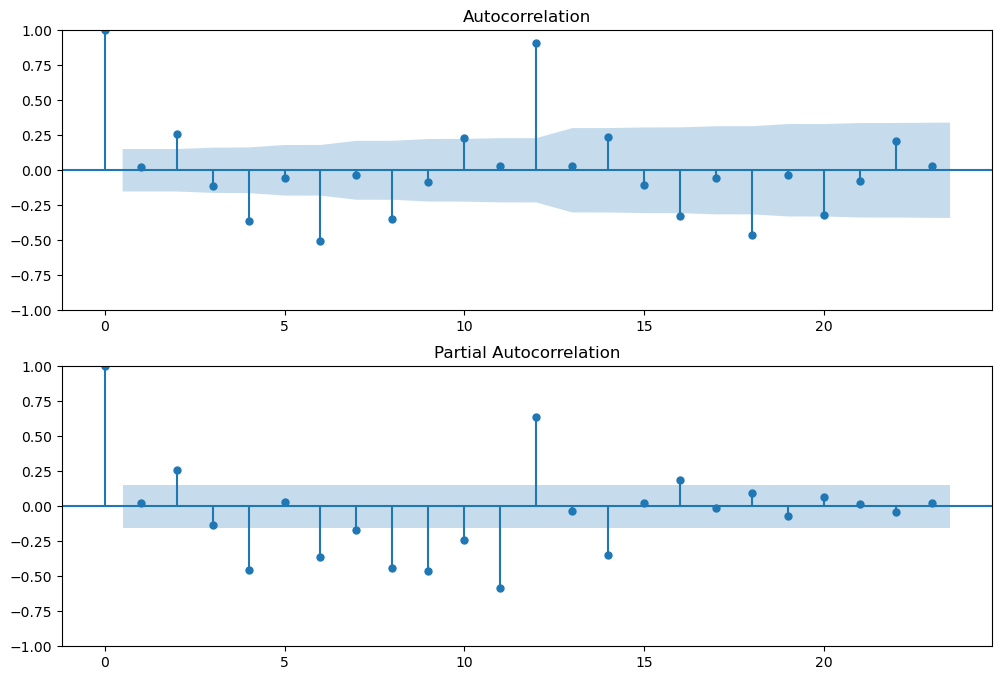

In [5]:
fig, ax = plt.subplots(2, 1, figsize = (12,8))
plot_acf(diff, ax = ax[0])
plot_pacf(diff, ax = ax[1])
plt.show()

In [6]:
y_train = df['Milk'].iloc[:-12]
y_test = df['Milk'].iloc[-12:]

In [7]:
model = ARIMA(y_train, order = (3,1,2))
model_fit = model.fit()

In [8]:
predictions = model_fit.predict(start = len(y_train), end = len(y_train) + len(y_test) -1, dynamic = False)
rmse = root_mean_squared_error(y_test, predictions)

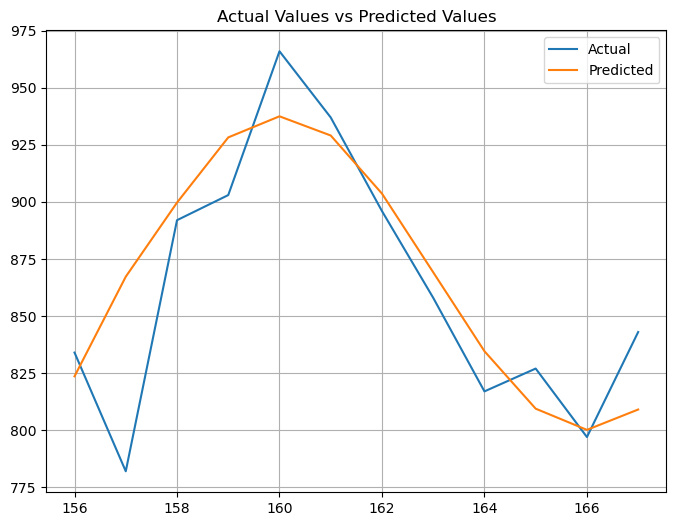

In [9]:
plt.figure(figsize=(8,6))
plt.plot(df['Milk'][-12:],label='Actual')
plt.plot(predictions,label='Predicted')
plt.title('Actual Values vs Predicted Values')
plt.legend()
plt.grid()
plt.show()

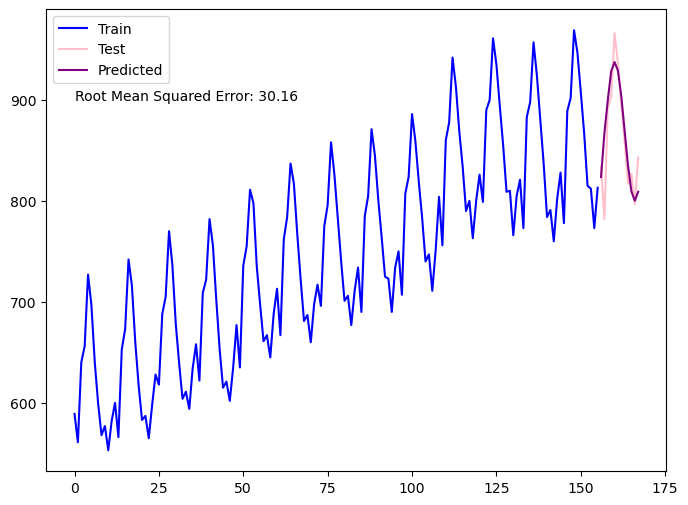

In [10]:
plt.figure(figsize=(8,6))
y_train.plot(color='blue',label='Train')
y_test.plot(color='pink',label='Test')
predictions.plot(color='purple',label='Predicted')
plt.text(0,900,f"Root Mean Squared Error: {rmse:.2f}")
plt.legend()
plt.show()

In [11]:
from pmdarima.arima import auto_arima

In [20]:
model = auto_arima(y_train, trace = True, error_Action = 'ignore', suppress_warnings=True)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=1593.685, Time=0.48 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1624.299, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1626.095, Time=0.05 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1626.164, Time=0.08 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1622.458, Time=0.01 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=1604.395, Time=0.24 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=1618.644, Time=0.21 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.45 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=1572.220, Time=0.50 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=inf, Time=0.30 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=inf, Time=0.60 sec
 ARIMA(2,1,4)(0,0,0)[0] intercept   : AIC=inf, Time=0.76 sec
 ARIMA(1,1,4)(0,0,0)[0] intercept   : AIC=1561.929, Time=0.78 sec
 ARIMA(0,1,4)(0,0,0)[0] intercept   : AIC=inf, Time=0.67 sec
 ARIMA(1,1,5)(0,0,0)[0] intercept   : AIC=inf, Time=0.74 s

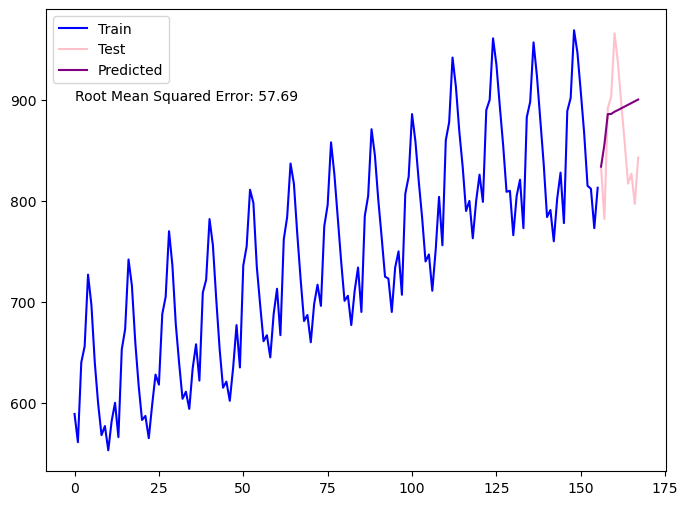

In [24]:
forecast_auto =  model.predict(n_periods=len(y_test))
plt.figure(figsize=(8,6))
y_train.plot(color='blue',label='Train')
y_test.plot(color='pink',label='Test')
forecast_auto.plot(color='purple',label='Predicted')
plt.text(0,900,f"Root Mean Squared Error: {root_mean_squared_error(y_test,forecast_auto):.2f}")
plt.legend()
plt.show()

In [18]:
s_model = auto_arima(y_train, trace = True, error_Action = 'ignore', seasonal=True, m = 12, suppress_warnings=True)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,1,1)[12] intercept   : AIC=1000.136, Time=1.10 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=1218.095, Time=0.04 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=1015.855, Time=0.29 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=1104.312, Time=0.30 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=1349.320, Time=0.04 sec
 ARIMA(2,0,2)(0,1,1)[12] intercept   : AIC=998.169, Time=0.83 sec
 ARIMA(2,0,2)(0,1,0)[12] intercept   : AIC=1038.230, Time=0.34 sec
 ARIMA(2,0,2)(0,1,2)[12] intercept   : AIC=1000.125, Time=1.66 sec
 ARIMA(2,0,2)(1,1,0)[12] intercept   : AIC=1012.395, Time=0.82 sec
 ARIMA(2,0,2)(1,1,2)[12] intercept   : AIC=inf, Time=2.94 sec
 ARIMA(1,0,2)(0,1,1)[12] intercept   : AIC=996.457, Time=0.54 sec
 ARIMA(1,0,2)(0,1,0)[12] intercept   : AIC=1036.989, Time=0.16 sec
 ARIMA(1,0,2)(1,1,1)[12] intercept   : AIC=998.423, Time=0.64 sec
 ARIMA(1,0,2)(0,1,2)[12] intercept   : AIC=998.411, Time=1.02 sec
 ARIMA(1,0,2)(1,1,0)[12] int

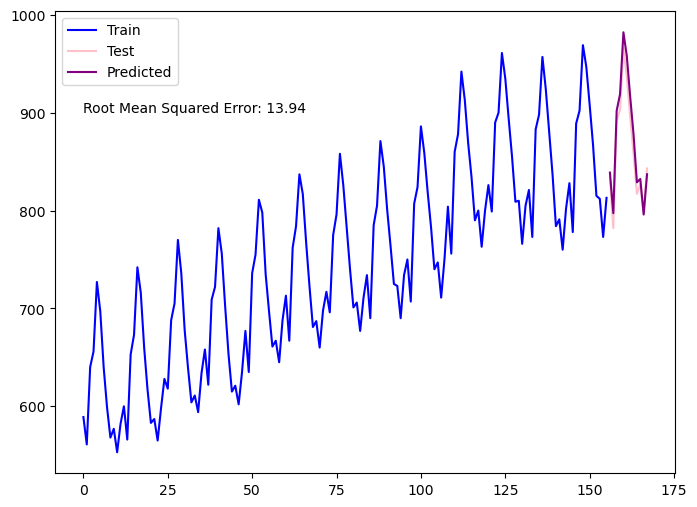

In [25]:
forecast =  s_model.predict(n_periods=len(y_test))
plt.figure(figsize=(8,6))
y_train.plot(color='blue',label='Train')
y_test.plot(color='pink',label='Test')
forecast.plot(color='purple',label='Predicted')
plt.text(0,900,f"Root Mean Squared Error: {root_mean_squared_error(y_test,forecast):.2f}")
plt.legend()
plt.show()